In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO

from trading_env_v2 import TradingEnvV2

In [2]:
stocks = ["AAPL", "AMZN", "JNJ", "JPM", "MSFT", "TSLA"]

test_data = []

for stock in stocks:
    df = pd.read_csv(f"data/test/{stock}.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    test_data.append(df)

In [3]:
env = TradingEnvV2(test_data)

model = PPO.load("models/ppo_continuous_trading")

In [4]:
obs, info = env.reset()

portfolio_values = []
prices = []
actions = []
dates = []
rewards = []

terminated = False
truncated = False

while not (terminated or truncated):

    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)

    portfolio_values.append(info["portfolio_value"])

    rewards.append(reward)

    actions.append(float(action[0]))

    prices.append(env.df.loc[env.current_step, "Close"])

    dates.append(env.df.loc[env.current_step, "Date"])

In [5]:
results = pd.DataFrame({
    "Date": dates,
    "Price": prices,
    "Action": actions,
    "Reward": rewards,
    "Portfolio": portfolio_values
})

results.head()

,Date,Price,Action,Reward,Portfolio
0,2023-10-24,216.520004,1.0,0.019415,10199.145719
1,2023-10-25,212.419998,1.0,-0.019436,10006.015482
2,2023-10-26,205.759995,1.0,-0.031853,9692.296904
3,2023-10-27,207.300003,1.0,0.006984,9764.838800
4,2023-10-30,197.360001,1.0,-0.048450,9296.616320


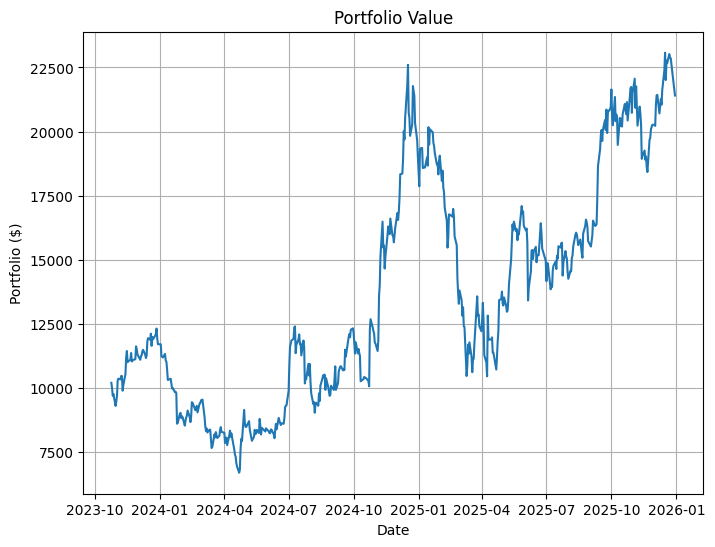

In [15]:
plt.figure(figsize=(8,6))

plt.plot(results["Date"], results["Portfolio"])

plt.title("Portfolio Value")

plt.xlabel("Date")

plt.ylabel("Portfolio ($)")

plt.grid(True)

plt.show()

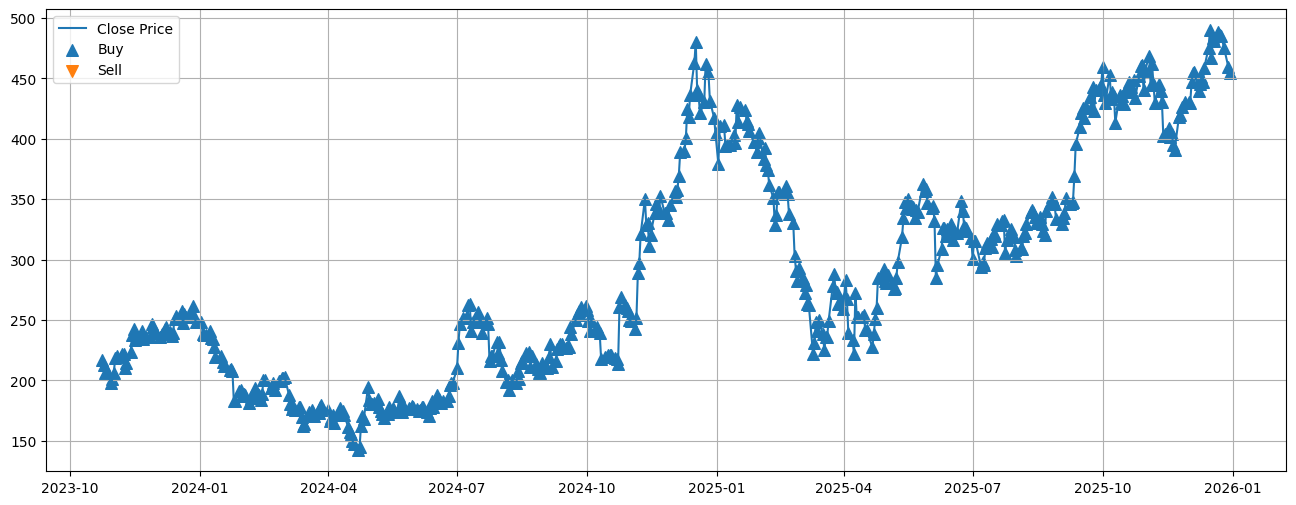

In [7]:
buy = results["Action"] > 0.2

sell = results["Action"] < -0.2

plt.figure(figsize=(16,6))

plt.plot(results["Date"], results["Price"], label="Close Price")

plt.scatter(
    results.loc[buy, "Date"],
    results.loc[buy, "Price"],
    marker="^",
    s=70,
    label="Buy"
)

plt.scatter(
    results.loc[sell, "Date"],
    results.loc[sell, "Price"],
    marker="v",
    s=70,
    label="Sell"
)

plt.legend()

plt.grid(True)

plt.show()

In [8]:
initial = portfolio_values[0]

final = portfolio_values[-1]

total_return = (final - initial) / initial

print(f"Initial Portfolio : ${initial:,.2f}")
print(f"Final Portfolio   : ${final:,.2f}")
print(f"Total Return      : {total_return:.2%}")

Initial Portfolio : $10,199.15
Final Portfolio   : $21,405.86
Total Return      : 109.88%


In [9]:
returns = pd.Series(portfolio_values).pct_change().dropna()

sharpe = np.sqrt(252) * returns.mean() / returns.std()

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.8567005953640774


In [10]:
portfolio = pd.Series(portfolio_values)

rolling_max = portfolio.cummax()

drawdown = (portfolio - rolling_max) / rolling_max

max_dd = drawdown.min()

print("Maximum Drawdown:", max_dd)

Maximum Drawdown: -0.537656801185852


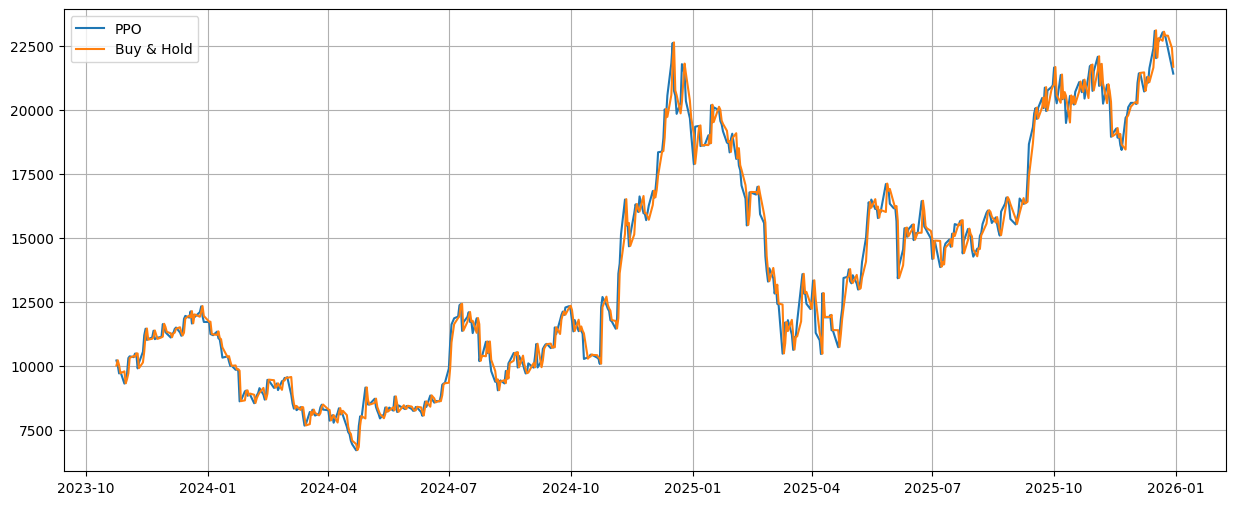

In [11]:
initial_cash = 10000

buy_price = env.df.iloc[0]["Close"]

shares = initial_cash / buy_price

buy_hold = shares * env.df["Close"].values

plt.figure(figsize=(15,6))

plt.plot(results["Date"], portfolio_values, label="PPO")

plt.plot(results["Date"], buy_hold[:len(results)], label="Buy & Hold")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
print("="*40)
print("PPO Trading Agent Evaluation")
print("="*40)

print(f"Initial Portfolio : ${initial:,.2f}")
print(f"Final Portfolio   : ${final:,.2f}")
print(f"Total Return      : {total_return:.2%}")
print(f"Sharpe Ratio      : {sharpe:.3f}")
print(f"Maximum Drawdown  : {max_dd:.2%}")

print("="*40)

PPO Trading Agent Evaluation
Initial Portfolio : $10,199.15
Final Portfolio   : $21,405.86
Total Return      : 109.88%
Sharpe Ratio      : 0.857
Maximum Drawdown  : -53.77%


In [13]:
results["Action"].describe()

count    548.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Action, dtype: float64

count    548.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Action, dtype: float64
[1.]


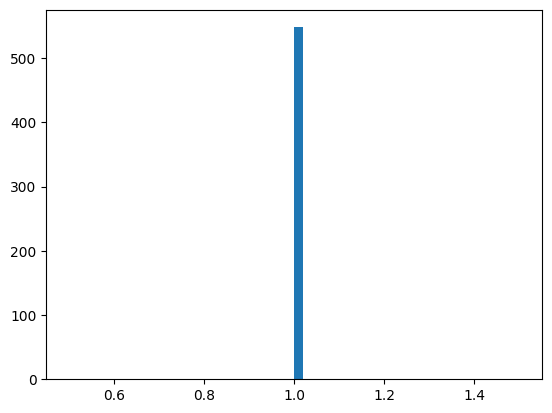

In [14]:
print(results["Action"].describe())

print(np.unique(np.round(actions, 2))[:30])

plt.hist(actions, bins=50)
plt.show()